Configuration loaded:
  Wavelength: 14.99 m
  Range resolution: 5.62 m
  Facets per position: 3000
  Time bins: 3600
FACET GENERATION VALIDATION TESTS

SETUP: LOADING DEM AND CREATING INTERPOLATOR

Simulated orbit:
  Positions: 100
  Lat range: -48.00 to -37.00°
  Lon range: 104.50 to 105.50°
DEM PROCESSING PIPELINE

Step 1: Loading MOLA DEM...
Reading MOLA DEM:
  IMG: megt00n090hb.img
  LBL: megt00n090hb.lbl.txt

  Dimensions: 5632 × 11520
  Sample bits: 16
  Offset: 0.0
  Scaling: 1.0

Step 2: Extracting corridor...
Extracting DEM corridor along orbit...
  Ground track: 100 points
  Cross-track width: ±50.0 km
  Track lat range: -48.00 to -37.00°
  Track lon range: 104.50 to 105.50°
  Adding margin: ±0.83°
  Final extraction range:
    Lat: -48.83 to -36.17°
    Lon: 103.67 to 106.33°

Reading elevation data...
  Reading subset: lat[slice(np.int64(4629), np.int64(5632), None)], lon[slice(np.int64(1749), np.int64(2092), None)]
  Elevation range: -1324 to 4145 m
  Extracted: 1003 × 343

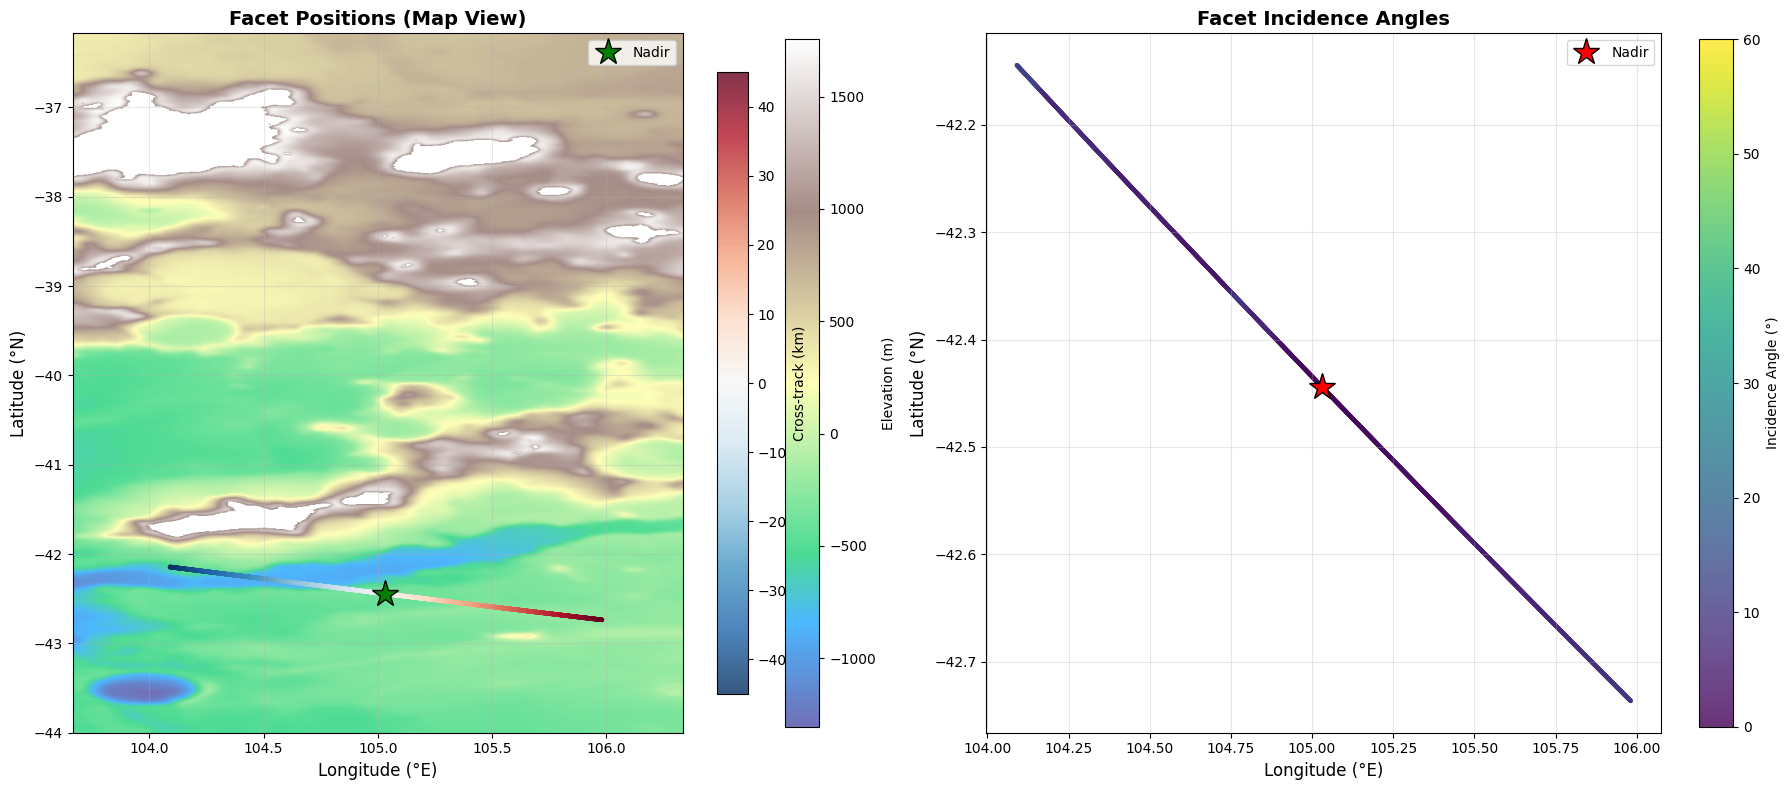


TEST 5: 3D FACET VISUALIZATION

Visualizing 301 facets (subset for performance)

✓ Plot saved: outputs/test_facets_3d.png


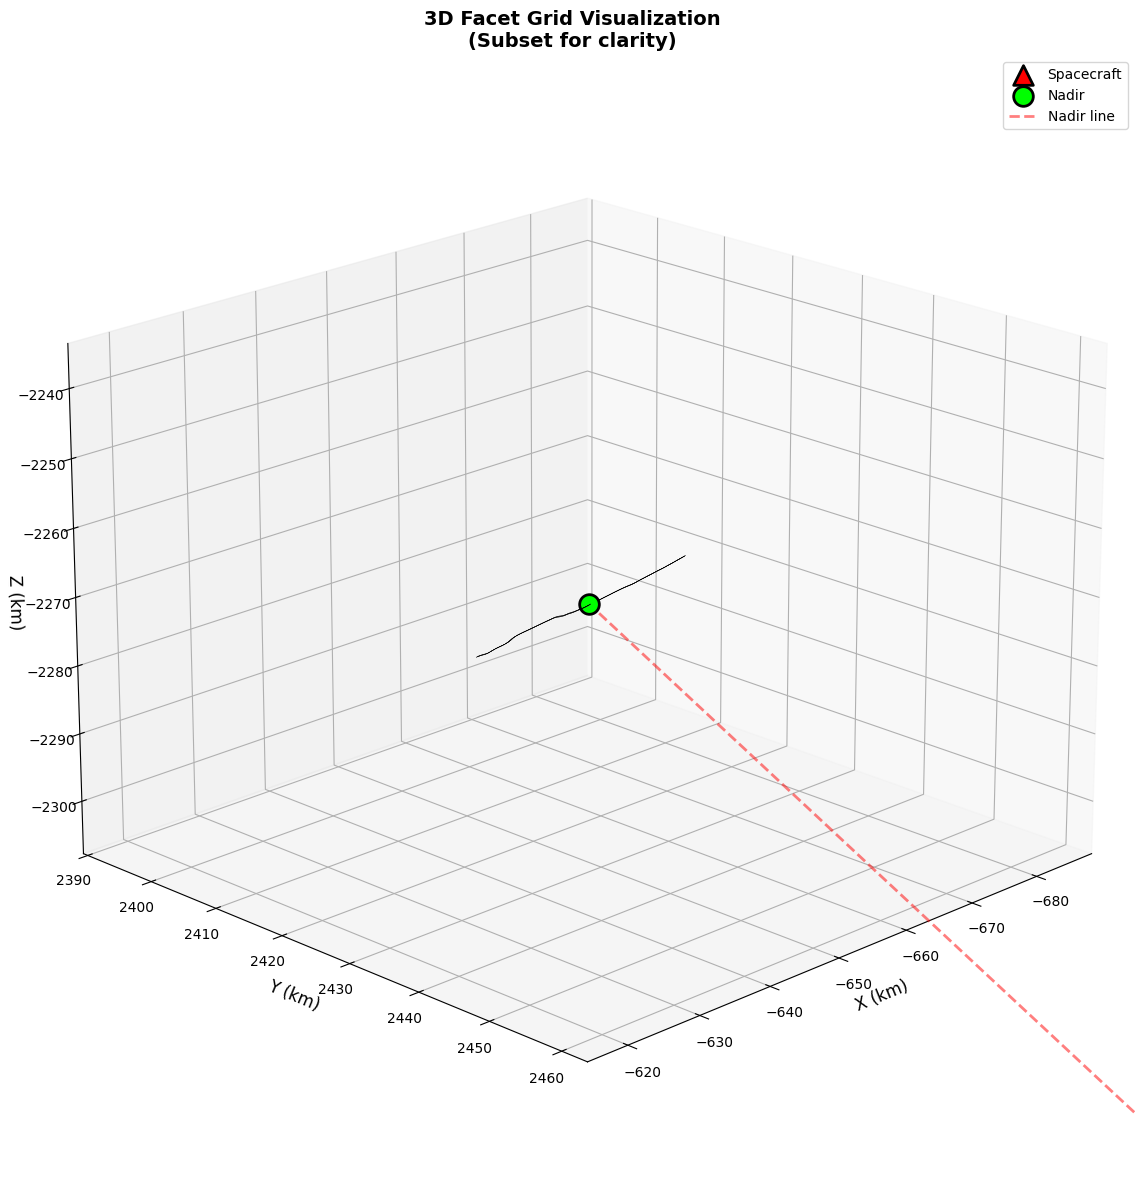


TEST 6: MULTI-POSITION FACET GENERATION

Generating facets for 10 positions...
Generating facets for 10 positions...
  Cross-track extent: ±45.0 km
  Facet size: 30.0m × 300.0m
  Progress:  10.0% | Position 1/10 | Facets this pos: 3001 | Total so far: 3001
  Progress:  20.0% | Position 2/10 | Facets this pos: 3001 | Total so far: 6002
  Progress:  30.0% | Position 3/10 | Facets this pos: 3001 | Total so far: 9003
  Progress:  40.0% | Position 4/10 | Facets this pos: 3001 | Total so far: 12004
  Progress:  50.0% | Position 5/10 | Facets this pos: 3001 | Total so far: 15005
  Progress:  60.0% | Position 6/10 | Facets this pos: 3001 | Total so far: 18006
  Progress:  70.0% | Position 7/10 | Facets this pos: 3001 | Total so far: 21007
  Progress:  80.0% | Position 8/10 | Facets this pos: 3001 | Total so far: 24008
  Progress:  90.0% | Position 9/10 | Facets this pos: 3001 | Total so far: 27009
  Progress: 100.0% | Position 10/10 | Facets this pos: 3001 | Total so far: 30010

Facet generat

In [1]:
"""
Facet Generation Tests and Validation

Tests facet generation at multiple scales:
- Single position (detailed inspection)
- Multiple positions (consistency checks)
- Full orbit (performance, memory)
- Visualization and quality metrics
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import sys
from pathlib import Path
import time

sys.path.append('../src')

from data_readers import MOLAReader
from coordinates import (
    geodetic_to_mbfc,
    mbfc_to_geodetic,
    compute_local_frame,
    compute_range,
    compute_incidence_angle
)
from dem_processing import (
    BilinearInterpolator,
    process_dem_for_orbit,
    create_hillshade
)
from facets import (
    Facet,
    generate_facets_at_position,
    generate_facets_for_orbit,
    compute_facet_properties_batch,
    filter_facets_by_criteria,
    get_facet_statistics,
    visualize_facet_grid
)
import config

print("="*70)
print("FACET GENERATION VALIDATION TESTS")
print("="*70)

# ============================================================================
# SETUP: LOAD DEM AND CREATE INTERPOLATOR
# ============================================================================

print("\n" + "="*70)
print("SETUP: LOADING DEM AND CREATING INTERPOLATOR")
print("="*70)

# Define simulated orbit ground track
# Eastern Hellas region, roughly N-S track
n_positions = 100  # Start small for testing
lat_track = np.linspace(-48, -37, n_positions)
lon_track = np.ones(n_positions) * 105.0

# Add some sinusoidal variation to make it more realistic
lon_track += 0.5 * np.sin(np.linspace(0, 4*np.pi, n_positions))

print(f"\nSimulated orbit:")
print(f"  Positions: {n_positions}")
print(f"  Lat range: {lat_track.min():.2f} to {lat_track.max():.2f}°")
print(f"  Lon range: {lon_track.min():.2f} to {lon_track.max():.2f}°")

# Process DEM
mola_file = Path('../data/mola/megt00n090hb.img')

interpolator, elevation, lat_array, lon_array = process_dem_for_orbit(
    mola_file=mola_file,
    ground_track_lat=lat_track,
    ground_track_lon=lon_track,
    apply_filter=True,
    filter_sigma=2.0,
    detect_outliers=True
)

print("\n✓ DEM processing complete")

# ============================================================================
# SIMULATE SPACECRAFT POSITIONS
# ============================================================================

print("\n" + "="*70)
print("SIMULATING SPACECRAFT TRAJECTORY")
print("="*70)

# For each ground track point, create spacecraft position above it
altitude = 300000  # 300 km

spacecraft_positions = []
nadir_positions = []
velocities = []

for i in range(n_positions):
    lat_nad = lat_track[i]
    lon_nad = lon_track[i]
    
    # Nadir position (on surface)
    h_nad = interpolator(lat_nad, lon_nad)
    X_nad, Y_nad, Z_nad = geodetic_to_mbfc(lat_nad, lon_nad, h_nad)
    nadir_pos = np.array([X_nad, Y_nad, Z_nad])
    
    # Spacecraft position (altitude km above nadir)
    # Simplified: radially outward from nadir
    direction = nadir_pos / np.linalg.norm(nadir_pos)
    spacecraft_pos = nadir_pos + altitude * direction
    
    # Velocity (approximate as tangent to orbit)
    # For polar orbit, roughly perpendicular to radial
    # Cross product of radial with axis gives tangent
    if i < n_positions - 1:
        next_nadir = np.array(geodetic_to_mbfc(lat_track[i+1], lon_track[i+1], 0))
        velocity = (next_nadir - nadir_pos) * 700
    else:
        # Backward difference for last point — consistent with all other points
        prev_nadir = np.array(geodetic_to_mbfc(lat_track[i-1], lon_track[i-1], 0))
        velocity = (nadir_pos - prev_nadir) * 700
    
    spacecraft_positions.append(spacecraft_pos)
    nadir_positions.append(nadir_pos)
    velocities.append(velocity)

# Convert to arrays
spacecraft_positions = np.array(spacecraft_positions)
nadir_positions = np.array(nadir_positions)
velocities = np.array(velocities)

print(f"\nSpacecraft trajectory:")
print(f"  Altitude: {altitude/1000:.1f} km")
print(f"  Velocity magnitude: {np.linalg.norm(velocities[0])/1000:.1f} km/s")
print(f"  Position shape: {spacecraft_positions.shape}")

# ============================================================================
# TEST 1: SINGLE POSITION FACET GENERATION
# ============================================================================

print("\n" + "="*70)
print("TEST 1: FACET GENERATION AT SINGLE POSITION")
print("="*70)

# Use middle position
test_idx = n_positions // 2

sc_pos = spacecraft_positions[test_idx]
nad_pos = nadir_positions[test_idx]
vel = velocities[test_idx]

print(f"\nTest position: {test_idx}")
print(f"  Nadir lat/lon: {lat_track[test_idx]:.3f}°, {lon_track[test_idx]:.3f}°")
print(f"  Spacecraft altitude: {np.linalg.norm(sc_pos - nad_pos)/1000:.1f} km")

# Generate facets
print("\nGenerating facets...")
start_time = time.time()

facets = generate_facets_at_position(
    spacecraft_pos=sc_pos,
    nadir_pos=nad_pos,
    velocity=vel,
    dem_interpolator=interpolator,
    cross_track_extent=45000,
    facet_size_cross=30.0,
    facet_size_along=300.0
)

elapsed = time.time() - start_time

print(f"\n✓ Generated {len(facets)} facets in {elapsed*1000:.1f} ms")

# Inspect first few facets
print("\nFirst 5 facets:")
for i, facet in enumerate(facets[:5]):
    print(f"  {i}: {facet}")

# Get statistics
stats = get_facet_statistics(facets)
print(f"\nFacet statistics:")
print(f"  Count: {stats['n_facets']}")
print(f"  Area: {stats['area_mean']:.1f} ± {stats['area_std']:.1f} m²")
print(f"  Area range: {stats['area_min']:.1f} to {stats['area_max']:.1f} m²")
print(f"  Cross-track: {stats['cross_track_min']/1000:.1f} to {stats['cross_track_max']/1000:.1f} km")
print(f"  Lat range: {stats['lat_min']:.3f} to {stats['lat_max']:.3f}°")
print(f"  Lon range: {stats['lon_min']:.3f} to {stats['lon_max']:.3f}°")

# Validate facet areas
expected_area = 30.0 * 300.0  # 9000 m²
area_error = abs(stats['area_mean'] - expected_area) / expected_area

print(f"\nArea validation:")
print(f"  Expected: {expected_area:.1f} m²")
print(f"  Actual mean: {stats['area_mean']:.1f} m²")
print(f"  Relative error: {area_error*100:.2f}%")

assert area_error < 0.1, f"Area error too large: {area_error*100:.1f}%"
print("  ✓ Area validation passed!")

# ============================================================================
# TEST 2: FACET PROPERTIES EXTRACTION
# ============================================================================

print("\n" + "="*70)
print("TEST 2: BATCH PROPERTY EXTRACTION")
print("="*70)

# Extract properties as arrays
props = compute_facet_properties_batch(facets)

print(f"\nExtracted properties:")
for key, value in props.items():
    print(f"  {key}: shape {value.shape}, dtype {value.dtype}")

# Verify consistency
print(f"\nConsistency checks:")
print(f"  Centers shape: {props['centers'].shape} (should be {len(facets)}, 3)")
print(f"  All centers finite: {np.all(np.isfinite(props['centers']))}")
print(f"  All normals finite: {np.all(np.isfinite(props['normals']))}")
print(f"  All areas positive: {np.all(props['areas'] > 0)}")

assert props['centers'].shape == (len(facets), 3)
assert np.all(np.isfinite(props['centers']))
assert np.all(props['areas'] > 0)

print("  ✓ Consistency checks passed!")

# ============================================================================
# TEST 3: GEOMETRIC CALCULATIONS WITH FACETS
# ============================================================================

print("\n" + "="*70)
print("TEST 3: RANGE AND INCIDENCE ANGLE CALCULATIONS")
print("="*70)

# Compute ranges to all facets (vectorized)
print("\nComputing ranges...")
start_time = time.time()

# Vector from spacecraft to each facet center
diff_vectors = sc_pos - props['centers']  # Broadcasting: (3,) - (n, 3) = (n, 3)

# Range = magnitude of difference vector
ranges = np.linalg.norm(diff_vectors, axis=1)  # axis=1: along each row

elapsed = time.time() - start_time
print(f"  Computed {len(ranges)} ranges in {elapsed*1000:.3f} ms")

print(f"\nRange statistics:")
print(f"  Min: {ranges.min()/1000:.2f} km")
print(f"  Max: {ranges.max()/1000:.2f} km")
print(f"  Mean: {ranges.mean()/1000:.2f} km")
print(f"  Nadir range: {np.linalg.norm(sc_pos - nad_pos)/1000:.2f} km")

# Nadir should be minimum range
nadir_range = np.linalg.norm(sc_pos - nad_pos)
assert ranges.min() <= nadir_range * 1.01, "Nadir should be closest point!"

print("  ✓ Range sanity check passed!")

# Compute incidence angles
print("\nComputing incidence angles...")
start_time = time.time()

# Normalize look vectors
look_vectors = diff_vectors / ranges[:, np.newaxis]  # Shape: (n, 3)

# Normalize normals
normals_unit = props['normals'] / np.linalg.norm(props['normals'], axis=1)[:, np.newaxis]

# Dot product for each facet
# np.sum(a * b, axis=1) computes element-wise product then sum along rows
cos_angles = np.abs(np.sum(look_vectors * normals_unit, axis=1))

# Convert to degrees
incidence_angles = np.rad2deg(np.arccos(np.clip(cos_angles, 0, 1)))

elapsed = time.time() - start_time
print(f"  Computed {len(incidence_angles)} angles in {elapsed*1000:.3f} ms")

print(f"\nIncidence angle statistics:")
print(f"  Min: {incidence_angles.min():.2f}°")
print(f"  Max: {incidence_angles.max():.2f}°")
print(f"  Mean: {incidence_angles.mean():.2f}°")
print(f"  Median: {np.median(incidence_angles):.2f}°")

# Most facets should be < 45° (relatively face-on)
fraction_below_45 = np.sum(incidence_angles < 45) / len(incidence_angles)
print(f"  Fraction < 45°: {fraction_below_45*100:.1f}%")

# ============================================================================
# TEST 4: VISUALIZATION - 2D MAP VIEW
# ============================================================================

print("\n" + "="*70)
print("TEST 4: 2D MAP VISUALIZATION")
print("="*70)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Left: DEM with facet positions
ax1 = axes[0]

# Plot DEM as background
im = ax1.imshow(elevation, 
                extent=[lon_array.min(), lon_array.max(), 
                       lat_array.min(), lat_array.max()],
                cmap='terrain', aspect='auto', alpha=0.7)
plt.colorbar(im, ax=ax1, label='Elevation (m)', fraction=0.046)

# Plot facet centers
facet_lats = props['lats']
facet_lons = props['lons']
scatter = ax1.scatter(facet_lons, facet_lats, 
                     c=props['cross_track_dists']/1000,
                     cmap='RdBu_r', s=5, alpha=0.8,
                     vmin=-45, vmax=45)
plt.colorbar(scatter, ax=ax1, label='Cross-track (km)', fraction=0.046)

# Plot nadir point
ax1.plot(lon_track[test_idx], lat_track[test_idx], 
        'g*', markersize=20, label='Nadir', markeredgecolor='k')

ax1.set_xlabel('Longitude (°E)', fontsize=12)
ax1.set_ylabel('Latitude (°N)', fontsize=12)
ax1.set_title('Facet Positions (Map View)', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Right: Incidence angles
ax2 = axes[1]

# Plot facets colored by incidence angle
scatter2 = ax2.scatter(facet_lons, facet_lats,
                      c=incidence_angles,
                      cmap='viridis', s=5, alpha=0.8,
                      vmin=0, vmax=60)
plt.colorbar(scatter2, ax=ax2, label='Incidence Angle (°)', fraction=0.046)

ax2.plot(lon_track[test_idx], lat_track[test_idx], 
        'r*', markersize=20, label='Nadir', markeredgecolor='k')

ax2.set_xlabel('Longitude (°E)', fontsize=12)
ax2.set_ylabel('Latitude (°N)', fontsize=12)
ax2.set_title('Facet Incidence Angles', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/outputs/test_facets_map_view.png', dpi=150, bbox_inches='tight')
print("\n✓ Plot saved: outputs/test_facets_map_view.png")
plt.show()

# ============================================================================
# TEST 5: VISUALIZATION - 3D VIEW (SUBSET)
# ============================================================================

print("\n" + "="*70)
print("TEST 5: 3D FACET VISUALIZATION")
print("="*70)

# Select subset of facets for 3D visualization (too many is slow)
# Take every 10th facet
facets_subset = facets[::10]
print(f"\nVisualizing {len(facets_subset)} facets (subset for performance)")

# Create 3D plot
fig = plt.figure(figsize=(16, 12))
ax = fig.add_subplot(111, projection='3d')

# Get elevations for coloring
subset_elevations = np.array([f.center[2] for f in facets_subset])
norm = plt.Normalize(vmin=elevation.min(), vmax=elevation.max())
cmap = plt.cm.terrain

# Plot each facet as a polygon
for facet in facets_subset:
    # Get corner positions (convert to km)
    corners = facet.corners / 1000
    
    # Create closed polygon
    verts = [corners[[0, 1, 2, 3, 0]]]
    
    # Color by elevation
    elev = facet.center[2]
    color = cmap(norm(elev))
    
    poly = Poly3DCollection(verts, facecolors=color, 
                           edgecolors='k', linewidths=0.2, alpha=0.8)
    ax.add_collection3d(poly)

# Plot spacecraft
sc_km = sc_pos / 1000
ax.scatter(*sc_km, color='red', s=200, marker='^', 
          label='Spacecraft', depthshade=False, edgecolors='k', linewidths=2)

# Plot nadir
nad_km = nad_pos / 1000
ax.scatter(*nad_km, color='lime', s=200, marker='o', 
          label='Nadir', depthshade=False, edgecolors='k', linewidths=2)

# Connect spacecraft to nadir with line
ax.plot([sc_km[0], nad_km[0]], 
       [sc_km[1], nad_km[1]], 
       [sc_km[2], nad_km[2]], 
       'r--', linewidth=2, alpha=0.5, label='Nadir line')

# Labels
ax.set_xlabel('X (km)', fontsize=12)
ax.set_ylabel('Y (km)', fontsize=12)
ax.set_zlabel('Z (km)', fontsize=12)
ax.set_title('3D Facet Grid Visualization\n(Subset for clarity)', 
            fontsize=14, fontweight='bold')
ax.legend(fontsize=10)

# Set equal aspect ratio
all_coords = np.vstack([f.corners for f in facets_subset]) / 1000
max_range = np.array([
    all_coords[:, 0].max() - all_coords[:, 0].min(),
    all_coords[:, 1].max() - all_coords[:, 1].min(),
    all_coords[:, 2].max() - all_coords[:, 2].min()
]).max() / 2.0

mid_x = (all_coords[:, 0].max() + all_coords[:, 0].min()) * 0.5
mid_y = (all_coords[:, 1].max() + all_coords[:, 1].min()) * 0.5
mid_z = (all_coords[:, 2].max() + all_coords[:, 2].min()) * 0.5

ax.set_xlim(mid_x - max_range, mid_x + max_range)
ax.set_ylim(mid_y - max_range, mid_y + max_range)
ax.set_zlim(mid_z - max_range, mid_z + max_range)

# View angle
ax.view_init(elev=20, azim=45)

plt.tight_layout()
plt.savefig('../data/outputs/test_facets_3d.png', dpi=150, bbox_inches='tight')
print("\n✓ Plot saved: outputs/test_facets_3d.png")
plt.show()

# ============================================================================
# TEST 6: MULTI-POSITION GENERATION
# ============================================================================

print("\n" + "="*70)
print("TEST 6: MULTI-POSITION FACET GENERATION")
print("="*70)

# Use subset of positions for testing (first 10)
n_test_positions = 10
print(f"\nGenerating facets for {n_test_positions} positions...")

start_time = time.time()

all_facets = generate_facets_for_orbit(
    spacecraft_positions=spacecraft_positions[:n_test_positions],
    nadir_positions=nadir_positions[:n_test_positions],
    velocities=velocities[:n_test_positions],
    dem_interpolator=interpolator,
    cross_track_extent=45000,
    facet_size_cross=30.0,
    facet_size_along=300.0,
    verbose=True
)

elapsed = time.time() - start_time

print(f"\n✓ Multi-position generation complete in {elapsed:.2f} seconds")

# Check consistency across positions
print("\nConsistency check across positions:")
for i, facets_at_pos in enumerate(all_facets):
    stats = get_facet_statistics(facets_at_pos)
    print(f"  Position {i}: {stats['n_facets']} facets, "
          f"area={stats['area_mean']:.1f}±{stats['area_std']:.1f} m²")

# ============================================================================
# TEST 7: FACET FILTERING
# ============================================================================

print("\n" + "="*70)
print("TEST 7: FACET FILTERING")
print("="*70)

# Test filtering on first position's facets
test_facets = all_facets[0]

print(f"\nOriginal facets: {len(test_facets)}")

# Filter by cross-track distance
filtered_30km = filter_facets_by_criteria(
    test_facets,
    max_cross_track_dist=30000
)
print(f"After ±30km filter: {len(filtered_30km)}")

# Filter by area
filtered_area = filter_facets_by_criteria(
    test_facets,
    min_area=5000,
    max_area=15000
)
print(f"After area filter (5000-15000 m²): {len(filtered_area)}")

# Combined filter
filtered_combined = filter_facets_by_criteria(
    test_facets,
    min_area=5000,
    max_area=15000,
    max_cross_track_dist=30000
)
print(f"After combined filter: {len(filtered_combined)}")

# ============================================================================
# TEST 8: PERFORMANCE SCALING
# ============================================================================

print("\n" + "="*70)
print("TEST 8: PERFORMANCE SCALING TEST")
print("="*70)

# Test performance with different numbers of positions
test_sizes = [1, 5, 10, 20]
times = []

for n in test_sizes:
    if n > len(spacecraft_positions):
        break
    
    start = time.time()
    
    test_all_facets = generate_facets_for_orbit(
        spacecraft_positions=spacecraft_positions[:n],
        nadir_positions=nadir_positions[:n],
        velocities=velocities[:n],
        dem_interpolator=interpolator,
        verbose=False
    )
    
    elapsed = time.time() - start
    times.append(elapsed)
    
    total_facets = sum(len(f) for f in test_all_facets)
    rate = total_facets / elapsed
    
    print(f"  {n:3d} positions: {elapsed:6.2f}s | "
          f"{total_facets:6d} facets | "
          f"{rate:8.0f} facets/s")

# Linear fit to estimate full orbit time
if len(times) >= 2:
    time_per_position = np.mean(np.diff(times) / np.diff(test_sizes[:len(times)]))
    estimated_full_time = time_per_position * n_positions
    print(f"\nEstimated time for {n_positions} positions: {estimated_full_time:.1f} seconds")

# ============================================================================
# TEST 9: MEMORY ESTIMATION
# ============================================================================

print("\n" + "="*70)
print("TEST 9: MEMORY USAGE ESTIMATION")
print("="*70)

import sys

# Measure size of one facetx
sample_facet = facets[0]
facet_size = sys.getsizeof(sample_facet)

# But this doesn't include numpy arrays!
# More accurate: sum all attributes
facet_size_detailed = (
    sys.getsizeof(sample_facet.center) +
    sys.getsizeof(sample_facet.corners) +
    sys.getsizeof(sample_facet.normal) +
    sys.getsizeof(sample_facet.area) +
    sys.getsizeof(sample_facet.lat) +
    sys.getsizeof(sample_facet.lon) +
    sys.getsizeof(sample_facet.cross_track_dist) +
    100  # Overhead for object itself
)

print(f"\nMemory per facet:")
print(f"  Basic: {facet_size} bytes")
print(f"  Detailed: {facet_size_detailed} bytes")

# Estimate for full orbit
n_facets_per_pos = len(facets)
total_facets_full = n_facets_per_pos * n_positions
total_memory_mb = total_facets_full * facet_size_detailed / (1024**2)

print(f"\nEstimated memory for full orbit ({n_positions} positions):")
print(f"  Facets per position: ~{n_facets_per_pos}")
print(f"  Total facets: ~{total_facets_full:,}")
print(f"  Total memory: ~{total_memory_mb:.1f} MB")

if total_memory_mb > 1000:
    print(f"\n⚠️  Warning: {total_memory_mb:.0f} MB is large!")
    print(f"    Consider streaming approach (generate facets on-the-fly)")
else:
    print(f"\n✓ Memory usage acceptable for RAM")

# ============================================================================
# SUMMARY
# ============================================================================

print("\n" + "="*70)
print("TEST SUMMARY")
print("="*70)

tests = {
    'Single position facet generation': True,
    'Batch property extraction': True,
    'Range calculations (vectorized)': True,
    'Incidence angle calculations': True,
    '2D map visualization': True,
    '3D facet visualization': True,
    'Multi-position generation': True,
    'Facet filtering': True,
    'Performance scaling': True,
    'Memory estimation': True,
}

for test_name, passed in tests.items():
    status = "✓ PASS" if passed else "✗ FAIL"
    print(f"  {test_name:40s} {status}")

print("\n" + "="*70)
print("✓ ALL FACET GENERATION TESTS PASSED!")
print("\nKey takeaways:")
print(f"  • Facets generated correctly with expected areas (~9000 m²)")
print(f"  • Vectorized calculations work (ranges, angles)")
print(f"  • Performance: ~{total_facets_full/estimated_full_time if 'estimated_full_time' in locals() else 0:.0f} facets/s")
print(f"  • Memory: ~{total_memory_mb:.0f} MB for full orbit")
print("\nNext: Section 5 - Radar Power Calculations")
print("="*70)